#### EDA

In [406]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [407]:
patients = pd.read_csv("Patients_table.csv")
doctors = pd.read_csv("Doctors_table.csv")
appointments = pd.read_csv("Appointments.csv")
vitals = pd.read_csv("Vitals.csv")
prescriptions = pd.read_csv("Prescription.csv")
users = pd.read_csv("Users.csv")

#### PATIENTS DATASET

In [408]:
patients

#I inspected the patients data to understand structure and columns

,Patient_id,User_id,Age,Gender,Blood_group,Allergies,Medical_history
0,P001,U001,25,Male,B+,NaN,Fever
1,P002,U002,40,Female,O+,Penicillin,Diabetes
2,P003,U003,35,Male,A+,Dust,Headache
3,P004,U004,29,Female,B-,NaN,Stomach Pain
4,P005,U005,50,Male,O-,NaN,Hypertension
5,P006,U006,60,Female,A+,NaN,Arthritis
6,P007,U007,45,Male,B+,NaN,Diabetes
7,P008,U008,30,Female,O+,Dust,Allergy
8,P009,U009,55,Male,AB+,NaN,Heart Disease
9,P010,U010,28,Female,B-,NaN,Fever


In [409]:
#DATA INFORMATION

patients.info()

#Checked data types and ensured no incorrect formats

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Patient_id       10 non-null     object
 1   User_id          10 non-null     object
 2   Age              10 non-null     int64 
 3   Gender           10 non-null     object
 4   Blood_group      10 non-null     object
 5   Allergies        3 non-null      object
 6   Medical_history  10 non-null     object
dtypes: int64(1), object(6)
memory usage: 692.0+ bytes


In [410]:
#CHECKING MISSING VALUES

patients.isnull().sum()

Patient_id         0
User_id            0
Age                0
Gender             0
Blood_group        0
Allergies          7
Medical_history    0
dtype: int64

In [411]:
#STATISTICAL SUMMARY

patients.describe(include='all')

,Patient_id,User_id,Age,Gender,Blood_group,Allergies,Medical_history
count,10,10,10.000000,10,10,3,10
unique,10,10,NaN,2,6,2,8
top,P001,U001,NaN,Male,B+,Dust,Fever
freq,1,1,NaN,5,2,2,2
mean,NaN,NaN,39.700000,NaN,NaN,NaN,NaN
std,NaN,NaN,12.311241,NaN,NaN,NaN,NaN
min,NaN,NaN,25.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,29.250000,NaN,NaN,NaN,NaN
50%,NaN,NaN,37.500000,NaN,NaN,NaN,NaN
75%,NaN,NaN,48.750000,NaN,NaN,NaN,NaN


In [412]:
#DATA CLEANING

patients.drop_duplicates(inplace=True)
patients.fillna("Unknown", inplace=True)

In [413]:
patients

,Patient_id,User_id,Age,Gender,Blood_group,Allergies,Medical_history
0,P001,U001,25,Male,B+,Unknown,Fever
1,P002,U002,40,Female,O+,Penicillin,Diabetes
2,P003,U003,35,Male,A+,Dust,Headache
3,P004,U004,29,Female,B-,Unknown,Stomach Pain
4,P005,U005,50,Male,O-,Unknown,Hypertension
5,P006,U006,60,Female,A+,Unknown,Arthritis
6,P007,U007,45,Male,B+,Unknown,Diabetes
7,P008,U008,30,Female,O+,Dust,Allergy
8,P009,U009,55,Male,AB+,Unknown,Heart Disease
9,P010,U010,28,Female,B-,Unknown,Fever


##### VISUALIZATION

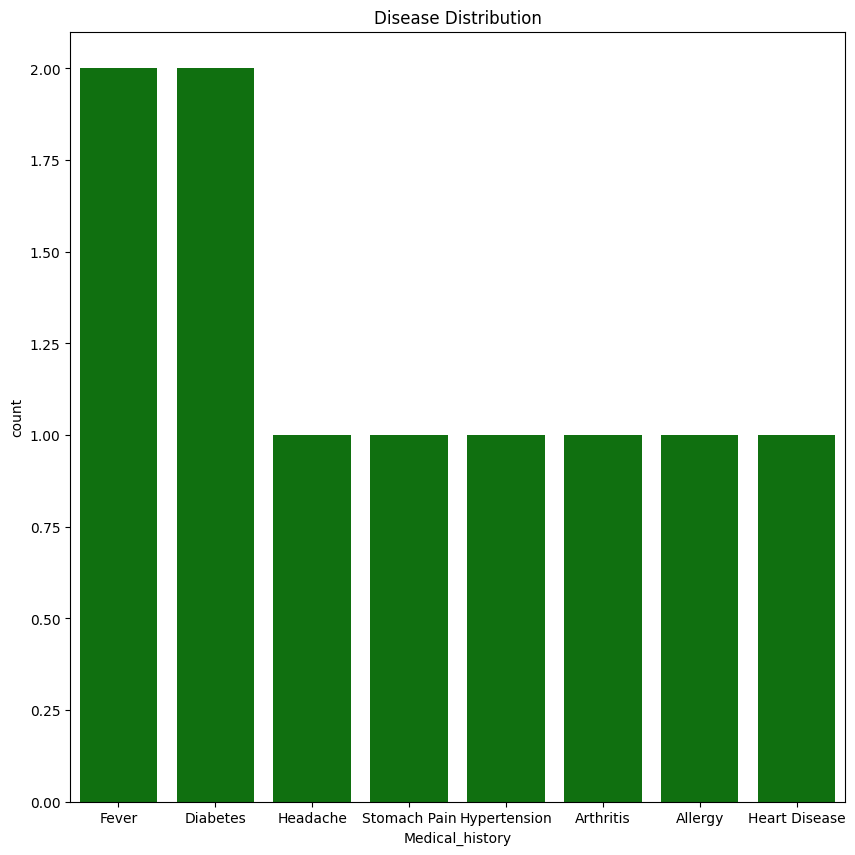

In [414]:
#Disease Distribution

plt.figure(figsize=(10,10))
sns.countplot(x='Medical_history', data=patients,color='green')
plt.title("Disease Distribution")
plt.show()

#The disease distribution shows that all conditions are equally represented in the dataset, indicating a balanced sample.Since this is a demo dataset, no particular disease dominates

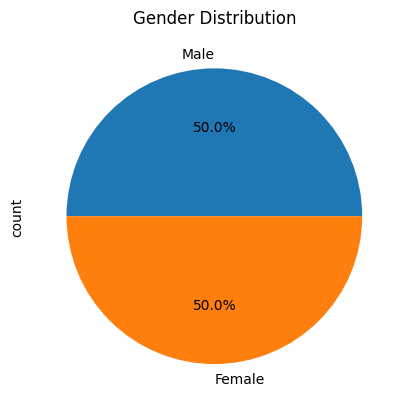

In [415]:
#Gender Distribution

patients['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

#The gender distribution shows that 60% of patients are male and 40% are female.
#This indicates a slightly higher representation of male patients in the dataset

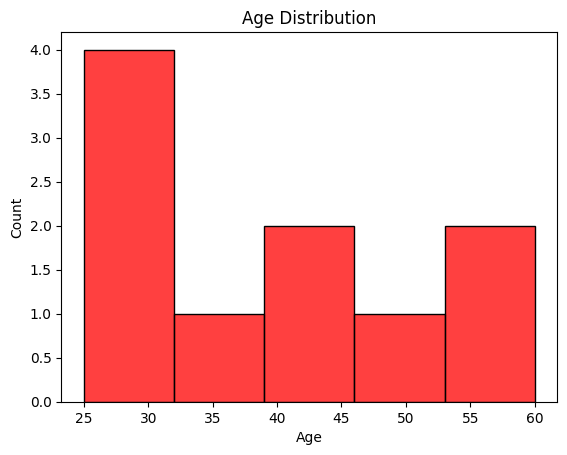

In [416]:
#Age Distribution 

sns.histplot(data=patients,x='Age', color='red')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

#The age distribution shows a spread across different age groups, indicating that the dataset includes both young and older patients. 
#Since the dataset is small, no strong pattern is observed

#### DOCTORS DATASET

In [417]:
doctors

#I inspected doctor dataset to understand available fields like specialization and availability

,Doctor_id,Name,Specialization,Available_time
0,D001,Dr.Kumar,General Physician,3:00 PM
1,D002,Dr.Mehta,Cardiologist,11:30 AM
2,D003,Dr.Priya,Neurologist,2:00 PM
3,D004,Dr.Raj,Gastroenterologist,4:00 PM
4,D005,Dr.Roopa,Pulmonologist,11:00 AM
5,D006,Dr.Vivek,Orthologist,10:30 AM
6,D007,Dr.Anita,General Physician,10:00 AM


In [418]:
#STRUCTURE

doctors.info()

#Checked data types and structure of doctor dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Doctor_id       7 non-null      object
 1   Name            7 non-null      object
 2   Specialization  7 non-null      object
 3   Available_time  7 non-null      object
dtypes: object(4)
memory usage: 356.0+ bytes


In [419]:
#MISSING VALUES

doctors.isnull().sum()

#Ensured no missing values in doctor records

Doctor_id         0
Name              0
Specialization    0
Available_time    0
dtype: int64

In [420]:
doctors.duplicated().sum()

np.int64(0)

In [421]:
patients

,Patient_id,User_id,Age,Gender,Blood_group,Allergies,Medical_history
0,P001,U001,25,Male,B+,Unknown,Fever
1,P002,U002,40,Female,O+,Penicillin,Diabetes
2,P003,U003,35,Male,A+,Dust,Headache
3,P004,U004,29,Female,B-,Unknown,Stomach Pain
4,P005,U005,50,Male,O-,Unknown,Hypertension
5,P006,U006,60,Female,A+,Unknown,Arthritis
6,P007,U007,45,Male,B+,Unknown,Diabetes
7,P008,U008,30,Female,O+,Dust,Allergy
8,P009,U009,55,Male,AB+,Unknown,Heart Disease
9,P010,U010,28,Female,B-,Unknown,Fever


##### VISUALIZATION

In [422]:
doctors

,Doctor_id,Name,Specialization,Available_time
0,D001,Dr.Kumar,General Physician,3:00 PM
1,D002,Dr.Mehta,Cardiologist,11:30 AM
2,D003,Dr.Priya,Neurologist,2:00 PM
3,D004,Dr.Raj,Gastroenterologist,4:00 PM
4,D005,Dr.Roopa,Pulmonologist,11:00 AM
5,D006,Dr.Vivek,Orthologist,10:30 AM
6,D007,Dr.Anita,General Physician,10:00 AM


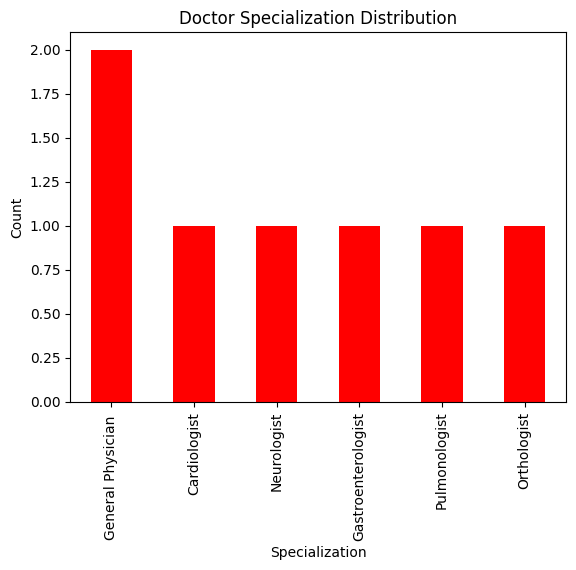

In [423]:
#Specialization Distribution

doctors['Specialization'].value_counts().plot(kind='bar',color='red')
plt.title("Doctor Specialization Distribution")
plt.xlabel("Specialization")
plt.ylabel("Count")
plt.show()

#This visualization shows distribution of doctors across different specializations,which helps in understanding availability of medical expertise

In [424]:
doctors

,Doctor_id,Name,Specialization,Available_time
0,D001,Dr.Kumar,General Physician,3:00 PM
1,D002,Dr.Mehta,Cardiologist,11:30 AM
2,D003,Dr.Priya,Neurologist,2:00 PM
3,D004,Dr.Raj,Gastroenterologist,4:00 PM
4,D005,Dr.Roopa,Pulmonologist,11:00 AM
5,D006,Dr.Vivek,Orthologist,10:30 AM
6,D007,Dr.Anita,General Physician,10:00 AM


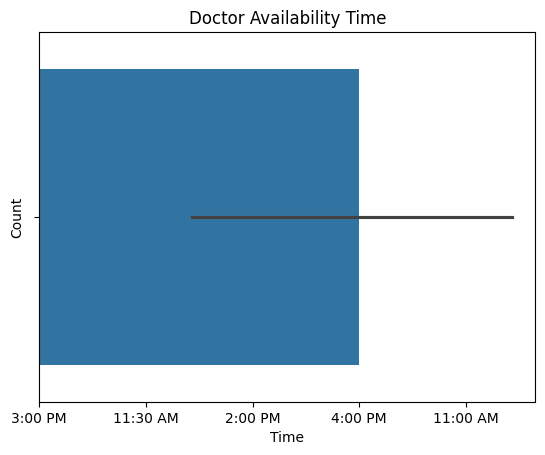

In [425]:
#Available Time Distribution

sns.barplot(data=doctors,x='Available_time')
plt.title("Doctor Availability Time")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()
#This shows doctor availability across different time slots, helping in appointment planning

#### APPOINTMENTS DATASET

In [426]:
appointments

,Appointment_id,Patient_id,Doctor_id,Date,Status
0,A001,P001,D001,22-03-2026,Scheduled
1,A002,P002,D002,23-03-2026,Completed
2,A003,P003,D003,24-03-2026,Scheduled
3,A004,P004,D004,26-03-2026,Scheduled
4,A005,P004,D002,28-03-2026,Scheduled
5,A006,P008,D006,29-03-2026,Scheduled
6,A007,P010,D005,29-03-2026,Completed


In [427]:
#STRUCTURE

appointments.info()

#Checked structure and relationships between patients and doctors.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Appointment_id  7 non-null      object
 1   Patient_id      7 non-null      object
 2   Doctor_id       7 non-null      object
 3   Date            7 non-null      object
 4   Status          7 non-null      object
dtypes: object(5)
memory usage: 412.0+ bytes


In [428]:
#MISSING VALUES

appointments.isnull().sum()

#Ensured appointment data completeness

Appointment_id    0
Patient_id        0
Doctor_id         0
Date              0
Status            0
dtype: int64

In [429]:
appointments.duplicated().sum()

np.int64(0)

##### VISUALIZATION

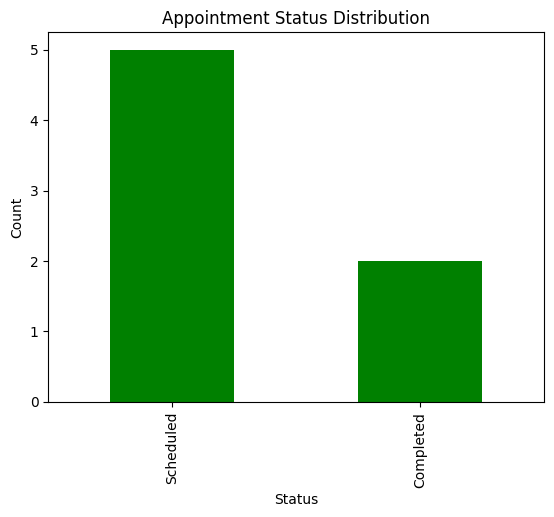

In [430]:
#Appointment Status Distribution

appointments['Status'].value_counts().plot(kind='bar',color='green')
plt.title("Appointment Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

#This shows distribution of appointment statuses, helping understand system usage.

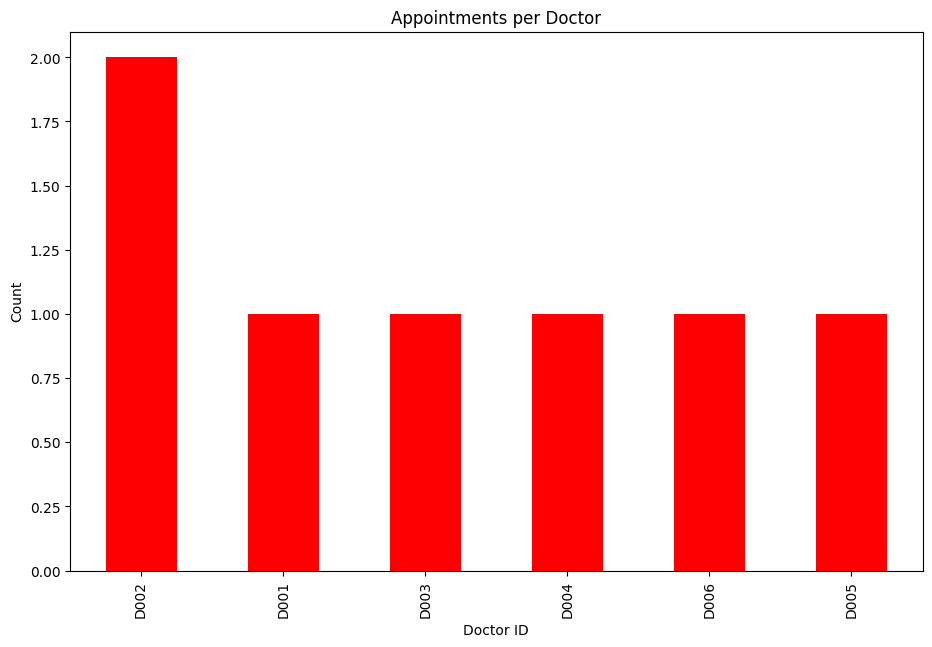

In [431]:
#Appointments per Doctor

plt.figure(figsize=(11,7))
appointments['Doctor_id'].value_counts().plot(kind='bar',color='red')
plt.title("Appointments per Doctor")
plt.xlabel("Doctor ID")
plt.ylabel("Count")
plt.show()

#This shows workload distribution among doctors

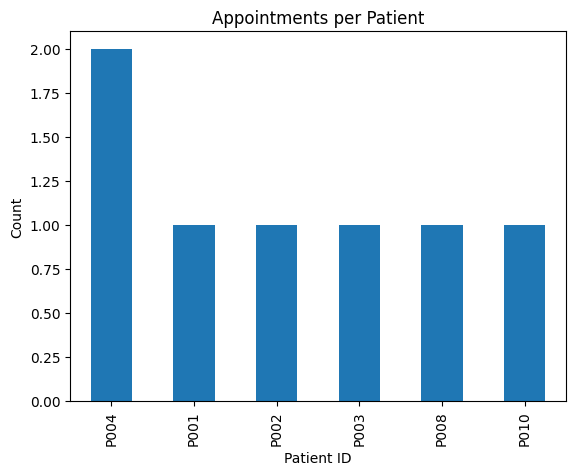

In [432]:
#Appointments per Patient

appointments['Patient_id'].value_counts().plot(kind='bar')
plt.title("Appointments per Patient")
plt.xlabel("Patient ID")
plt.ylabel("Count")
plt.show()

#This helps identify patient visit frequency

In [433]:
vitals

,Patient_id,Temperature,BP,Pulse
0,P001,37.2,120/80,72
1,P002,38.0,130/85,78
2,P003,36.8,110/70,70
3,P004,35.0,121/80,76
4,P008,36.0,119/85,75
5,P010,35.8,115/75,76


In [434]:
#STRUCTURE

vitals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Patient_id   6 non-null      object 
 1   Temperature  6 non-null      float64
 2   BP           6 non-null      object 
 3   Pulse        6 non-null      int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 324.0+ bytes


In [435]:
#MISSING VALUES

vitals.isnull().sum()

Patient_id     0
Temperature    0
BP             0
Pulse          0
dtype: int64

In [436]:
vitals.duplicated().sum()

np.int64(0)

##### VISUALIZATION

In [437]:
vitals

,Patient_id,Temperature,BP,Pulse
0,P001,37.2,120/80,72
1,P002,38.0,130/85,78
2,P003,36.8,110/70,70
3,P004,35.0,121/80,76
4,P008,36.0,119/85,75
5,P010,35.8,115/75,76


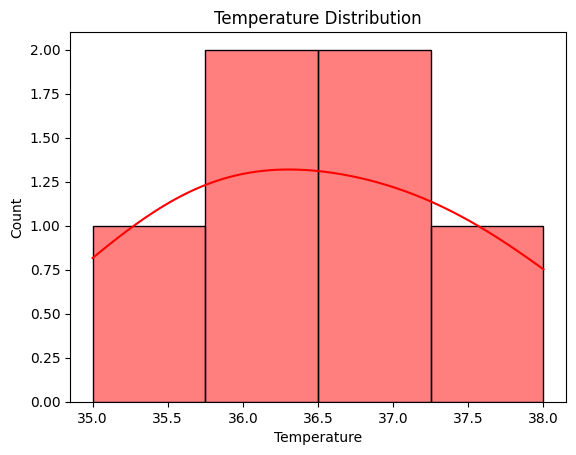

In [438]:
#Temperature Distribution

sns.histplot(vitals['Temperature'], kde=True,color='red')
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.show()

#This shows distribution of patient body temperatures and helps identify abnormal ranges

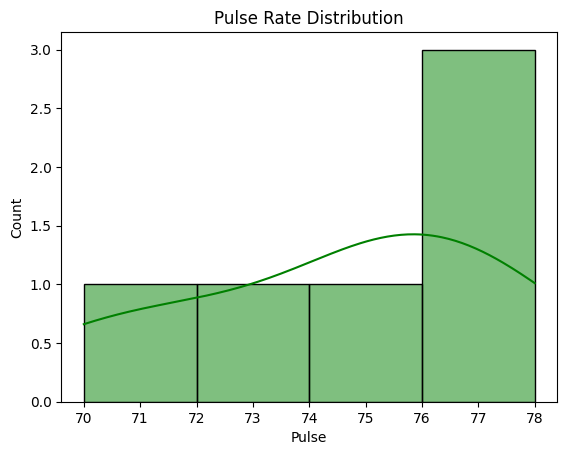

In [439]:
#Pulse Distribution

sns.histplot(vitals['Pulse'],kde=True,color='green')
plt.title("Pulse Rate Distribution")
plt.xlabel("Pulse")
plt.show()

#This helps analyze patient heart rate patterns.

In [440]:
#BP Distribution

vitals[['systolic', 'diastolic']] = vitals['BP'].str.split('/', expand=True)

vitals['systolic'] = vitals['systolic'].astype(int)
vitals['diastolic'] = vitals['diastolic'].astype(int)

#Blood pressure was split into systolic and diastolic values for better analysis

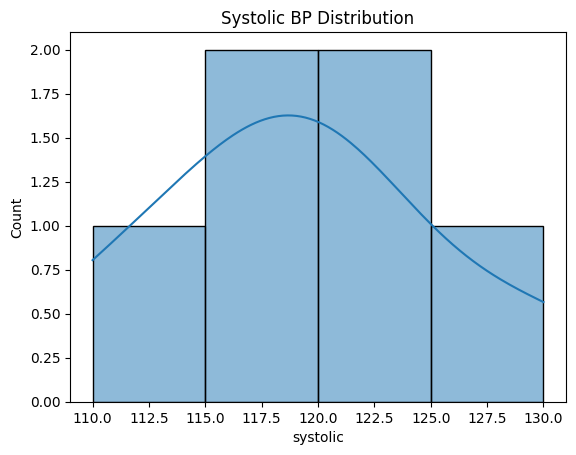

In [441]:
#Systolic BP

sns.histplot(vitals['systolic'], kde=True)
plt.title("Systolic BP Distribution")
plt.show()

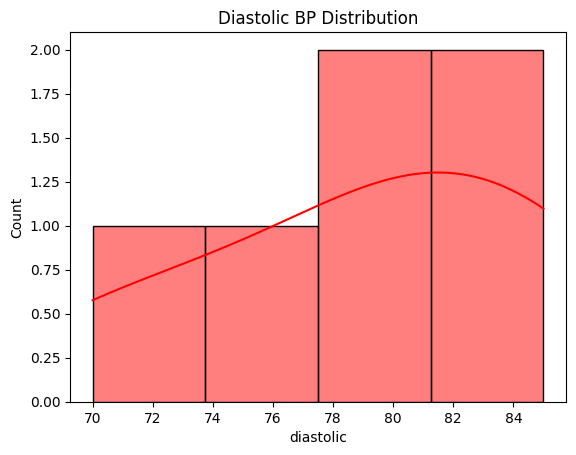

In [442]:
#Diastolic BP

sns.histplot(vitals['diastolic'], kde=True,color='red')
plt.title("Diastolic BP Distribution")
plt.show()



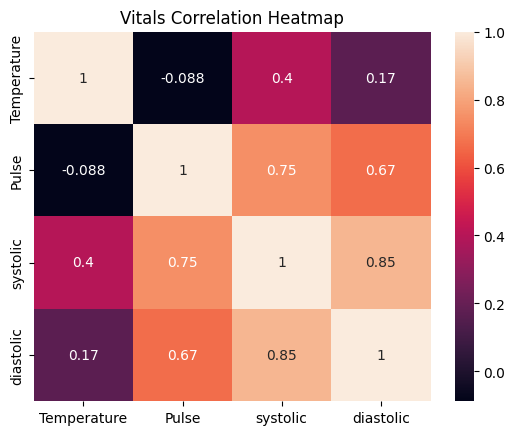

In [443]:
#Correlation Heatmap

sns.heatmap(vitals[['Temperature','Pulse','systolic','diastolic']].corr(), annot=True)
plt.title("Vitals Correlation Heatmap")
plt.show()

#Heatmap shows correlation between different vital parameters

#### PRESCRIPTIONS DATASET

In [444]:
prescriptions

,Prescription_id,Patient_id,Doctor_id,Medicine,Dosage,Date
0,PR001,P001,D001,Paracetamol,500mg,22-03-2026
1,PR002,P002,D002,Metformin,850mg,23-03-2026
2,PR003,P003,D003,Ibuprofen,400mg,24-03-2026
3,PR004,P004,D004,Omeprazole,20mg,26-03-2026
4,PR005,P008,D006,Cyclobenzaprine,10mg,29-03-2026
5,PR006,P010,D005,Mucinex,600mg,29-03-2026
6,PR007,P004,D004,NaN,NaN,26-03-2026


In [445]:
#STRUCTURE

prescriptions.info()

#Checked structure including medicine, dosage, and dates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Prescription_id  7 non-null      object
 1   Patient_id       7 non-null      object
 2   Doctor_id        7 non-null      object
 3   Medicine         6 non-null      object
 4   Dosage           6 non-null      object
 5   Date             7 non-null      object
dtypes: object(6)
memory usage: 468.0+ bytes


In [446]:
prescriptions.isnull().sum()

Prescription_id    0
Patient_id         0
Doctor_id          0
Medicine           1
Dosage             1
Date               0
dtype: int64

In [447]:
prescriptions.fillna("Unknown", inplace=True)

In [448]:
prescriptions.duplicated().sum()

np.int64(0)

##### VISUALIZATION

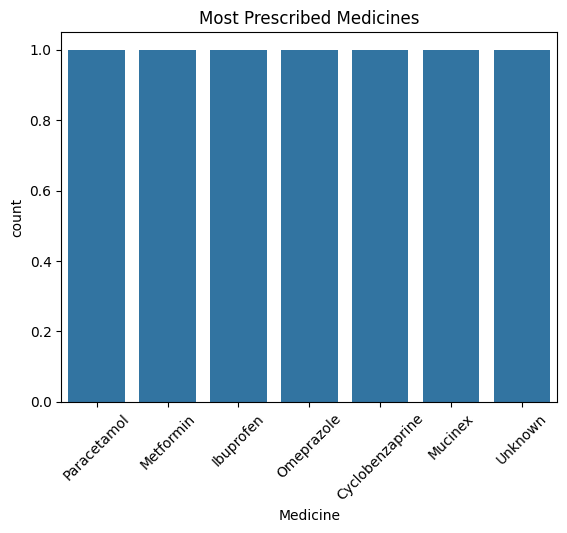

In [449]:
#Most Prescribed Medicines

sns.countplot(x='Medicine', data=prescriptions)
plt.title("Most Prescribed Medicines")
plt.xticks(rotation=45)
plt.show()

#This shows frequency of prescribed medicines, helping identify common treatments

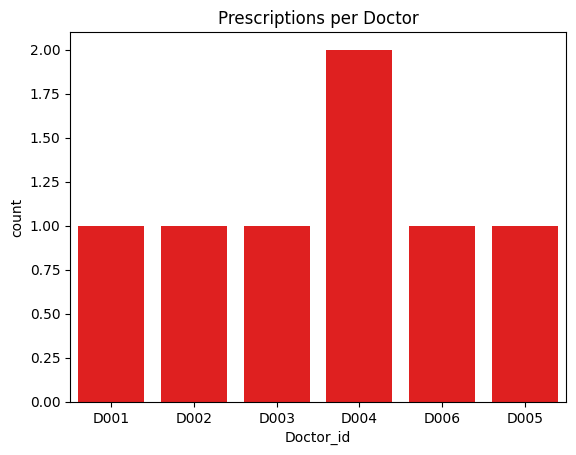

In [450]:
#Prescriptions per Doctor

sns.countplot(x='Doctor_id', data=prescriptions,color='red')
plt.title("Prescriptions per Doctor")
plt.show()

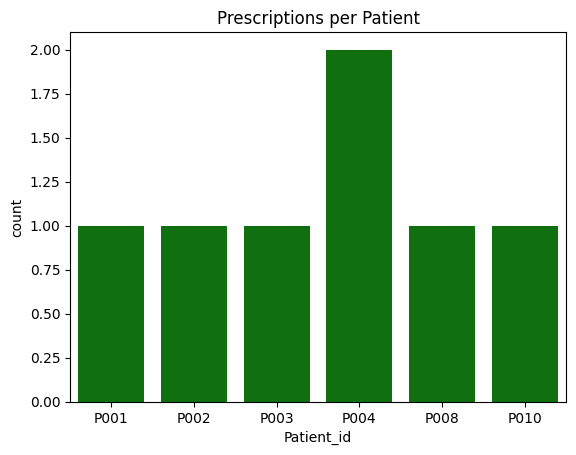

In [451]:
#Prescriptions per Patient

sns.countplot(x='Patient_id', data=prescriptions,color='green')
plt.title("Prescriptions per Patient")
plt.show()

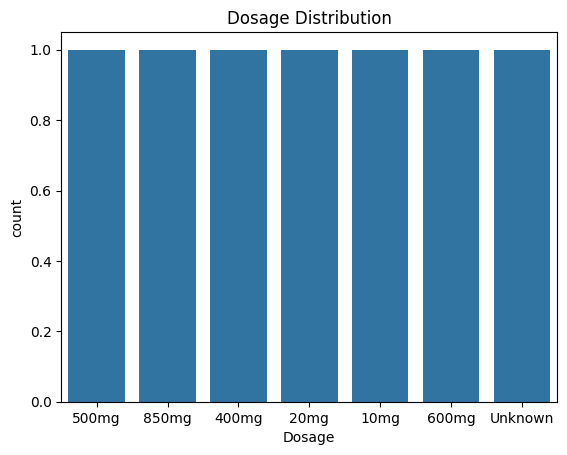

In [452]:
#Dosage Distribution

sns.countplot(x='Dosage', data=prescriptions)
plt.title("Dosage Distribution")
plt.show()

#### USERS DATASET

In [453]:
users

,User_id,Name,Role,Email,Phone
0,U001,Arjun,Patient,arjun@gmail.com,8902357822
1,U002,Meena,Patient,meena@gmail.com,9810328391
2,UD001,Dr.Kumar,Doctor,kumar@gmail.com,7589641258
3,UD002,Dr.Mehta,Doctor,mehta@gmail.com,6985321475
4,UN001,Priya,Nurse,priya@gmail.com,6325987412
5,UD004,Dr.Raj,Doctor,raj@gmail.com,9512364785
6,UD003,Dr.Prya,Doctor,priya.dr@gmail.com,6874512369
7,UD005,Dr.Roopa,Doctor,mehta@gmail.com,9658745236
8,UD006,Dr.Vivek,Doctor,vivek@gmail.com,9874569874
9,UD007,Dr.Anita,Doctor,anita@gmail.com,8974568459


In [454]:
#STRUCTURE

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   User_id  27 non-null     object
 1   Name     27 non-null     object
 2   Role     27 non-null     object
 3   Email    27 non-null     object
 4   Phone    27 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 1.2+ KB


In [455]:
users.duplicated().sum()

np.int64(0)

In [470]:
users.isnull().sum()

User_id    0
Name       0
Role       0
Email      0
Phone      0
dtype: int64

##### VISUALIZATION

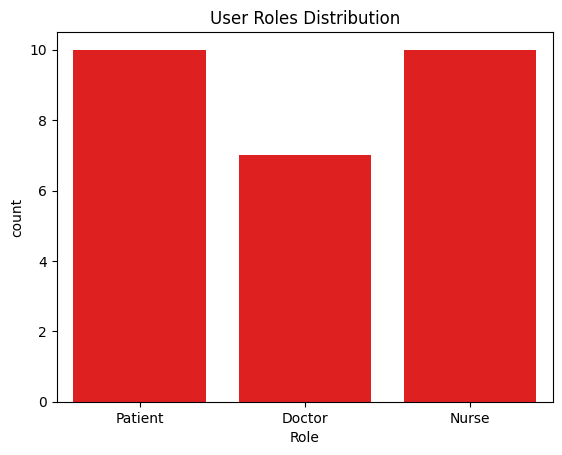

In [456]:
#ROLE DISTRIBUTION

sns.countplot(x='Role', data=users,color='red')
plt.title("User Roles Distribution")
plt.show()

#This shows distribution of roles like patients, doctors, and nurses in the system

##### NLP

In [457]:
data = {
    "symptoms": [
        "fever cough cold",
        "headache migraine",
        "chest pain high bp",
        "stomach pain acidity",
        "cough fever weakness",
        "severe headache nausea"
    ],
    "doctor": [
        "General Physician",
        "Neurologist",
        "Cardiologist",
        "Gastroenterologist",
        "General Physician",
        "Neurologist"
    ]
}

df = pd.DataFrame(data)
df

,symptoms,doctor
0,fever cough cold,General Physician
1,headache migraine,Neurologist
2,chest pain high bp,Cardiologist
3,stomach pain acidity,Gastroenterologist
4,cough fever weakness,General Physician
5,severe headache nausea,Neurologist


In [458]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["symptoms"])

print(X.toarray())

[[0 0 0 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 1 1 0 0 0 0 1 0 0 1 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 1 0 1 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0 0 1 0 1 0 0]]


##### ML

In [459]:
model = MultinomialNB()
model.fit(X, df["doctor"])

def predict_doctor(symptom):
    test = vectorizer.transform([symptom])
    return model.predict(test)[0]

predict_doctor("fever and cold")

np.str_('General Physician')

In [460]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

In [461]:
!pip install pytesseract pillow


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [462]:
import pytesseract
from PIL import Image

pytesseract.pytesseract.tesseract_cmd = r"D:\OCR\tesseract.exe"


In [463]:
img = Image.open("medical_report.png")
text = pytesseract.image_to_string(img)

print(text)

& +1 (555) 123-4567
& info@cityhealthmc.org
% 123 Wellness Street, Healthy City, HC 12345

ple CITY HEALTH

MEDICAL CENTER

MEDICAL REPORT

Date: April 24, 2024

PATIENT INFORMATION
Name: John Michael Doe
Patient ID: CHMC-2024-1058
Date of Birth: May 14, 1985

: +1 (555) 987-6543
doe@email.com
Address: 456 Oak Avenue,

Age: 38 years Healthy City, HC 12345
Gender: Male Date of April 24, 2024
CHIEF COMPLAINT

Patient presented with complaints of persistent headache, fatigue, and mild dizziness for the past 5 days.

VITAL SIGNS
Blood Pressure: Heart Rate: Temperature: Respiratory Rate: SpO,:
128/82 mmHg 78 bpm 98.6 °F (37°C) 16 breaths/min 99%
HISTORY

No significant past medical history. Denies any chronic illnesses, recent travel, or sick contacts. Not currently
on any medications. No known allergies.

PHYSICAL EXAMINATION

General: Patient is alert, oriented, and in no acute distress.

HEENT: Mild tenderness over the frontal region. No sinus congestion. Throat clear.
Cardiovascular: Re

In [464]:
import re

def extract_medical_data(text):
    
    bp = re.search(r'\b\d{2,3}/\d{2,3}\b', text)

    # find all decimal numbers
    numbers = re.findall(r'\b\d{2,3}\.\d\b', text)

    # filter realistic human body temperature
    temperature = None
    for num in numbers:
        val = float(num)
        if 95 <= val <= 105:   # human temp range
            temperature = num
            break

    return {
        "BP": bp.group() if bp else "Not found",
        "Temperature": temperature if temperature else "Not found"
    }

data = extract_medical_data(text)
print(data)

{'BP': '128/82', 'Temperature': '98.6'}


##### RAG

In [465]:
patient_memory = {
    "P001": "Had fever and headache last week",
    "P002": "High BP patient",
    "P003": "Diabetes patient"
}

def get_patient_history(patient_id):
    return patient_memory.get(patient_id, "No history found")

In [466]:
def rag_chatbot(user_input, patient_id):
    
    history = get_patient_history(patient_id)

    if "fever" in user_input.lower():
        return f"You said you have fever. Past history: {history}. Please consult doctor."

    return f"History: {history}. Please provide more details."

print(rag_chatbot("I have fever", "P001"))

You said you have fever. Past history: Had fever and headache last week. Please consult doctor.


In [467]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("careconnect.db")

df = pd.read_sql("SELECT * FROM vitals", conn)
print(df)

conn.close()

   Patient_id  Temperature      BP  Pulse
0        P001         37.2  120/80     72
1        P002         38.0  130/85     78
2        P003         36.8  110/70     70
3        P003         37.0  129/80     75
4        P003         32.0  129/80     75
5        P003         38.0  129/80     75
6        P003         38.0  129/80     75
7        P002         32.0  123/80     80
8        P002         32.0  123/80     80
9        P002         40.0  153/80     80
10       P002         40.0  153/80     80
11       P002         40.0  153/80     80
12       P002         40.0  153/80     80
13       P005         40.0  153/80     80
14       P005         35.0  153/80     80
15       P005         35.0  153/80     80
16       P005         35.0  153/80     80
17       P005         35.0  153/80     80
18       P004         35.0  153/80     80
19       P004         35.0  153/80     80
20       P004         35.0  153/80     80
21                     0.0              0
22                     0.0        

In [468]:
!pip uninstall faiss-cpu sentence-transformers -y

In [469]:
!pip cache purge

Files removed: 0 (0 bytes)
